In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import gaussian_kde



In [3]:
df_floor7 = pd.read_csv('../data/cu-bem/2019Floor7.csv/2019Floor7.csv')

In [4]:
df_floor7.head()

,Date,z1_AC1(kW),z1_AC2(kW),z1_AC3(kW),z1_AC4(kW),z1_Light(kW),z1_Plug(kW),z1_S1(degC),z1_S1(RH%),z1_S1(lux),...,z4_Plug(kW),z4_S1(degC),z4_S1(RH%),z4_S1(lux),z5_AC1(kW),z5_Light(kW),z5_Plug(kW),z5_S1(degC),z5_S1(RH%),z5_S1(lux)
0,2019-01-01 00:00:00,0.0,0.0,0.01,0.0,0.0,0.13,NaN,NaN,NaN,...,0.01,NaN,NaN,NaN,0.0,0.0,0.08,NaN,NaN,NaN
1,2019-01-01 00:01:00,0.0,0.0,0.01,0.0,0.0,0.12,NaN,NaN,NaN,...,0.01,NaN,NaN,NaN,0.0,0.0,0.08,NaN,NaN,NaN
2,2019-01-01 00:02:00,0.0,0.0,0.01,0.0,0.0,0.13,NaN,NaN,NaN,...,0.01,NaN,NaN,NaN,0.0,0.0,0.08,NaN,NaN,NaN
3,2019-01-01 00:03:00,0.0,0.0,0.01,0.0,0.0,0.12,NaN,NaN,NaN,...,0.01,NaN,NaN,NaN,0.0,0.0,0.08,NaN,NaN,NaN
4,2019-01-01 00:04:00,0.0,0.0,0.01,0.0,0.0,0.12,NaN,NaN,NaN,...,0.01,NaN,NaN,NaN,0.0,0.0,0.08,NaN,NaN,NaN


In [5]:
df_floor7.tail()

,Date,z1_AC1(kW),z1_AC2(kW),z1_AC3(kW),z1_AC4(kW),z1_Light(kW),z1_Plug(kW),z1_S1(degC),z1_S1(RH%),z1_S1(lux),...,z4_Plug(kW),z4_S1(degC),z4_S1(RH%),z4_S1(lux),z5_AC1(kW),z5_Light(kW),z5_Plug(kW),z5_S1(degC),z5_S1(RH%),z5_S1(lux)
525595,2019-12-31 23:55:00,0.0,0.01,0.0,0.0,0.0,0.05,27.93,53.80,0.0,...,0.07,28.50,55.96,0.0,0.0,0.0,0.03,29.43,52.86,0.0
525596,2019-12-31 23:56:00,0.0,0.01,0.0,0.0,0.0,0.05,27.94,53.83,0.0,...,0.07,28.49,55.96,0.0,0.0,0.0,0.03,29.43,52.87,0.0
525597,2019-12-31 23:57:00,0.0,0.01,0.0,0.0,0.0,0.05,27.93,53.84,0.0,...,0.07,28.50,56.00,0.0,0.0,0.0,0.03,29.42,52.84,0.0
525598,2019-12-31 23:58:00,0.0,0.01,0.0,0.0,0.0,0.04,27.93,53.87,0.0,...,0.07,28.49,56.10,0.0,0.0,0.0,0.03,29.41,52.87,0.0
525599,2019-12-31 23:59:00,0.0,0.01,0.0,0.0,0.0,0.04,27.94,53.86,0.0,...,0.07,28.49,56.20,0.0,0.0,0.0,0.03,29.41,52.91,0.0


In [6]:
df_floor7.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 30 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Date          525600 non-null  object 
 1   z1_AC1(kW)    521187 non-null  float64
 2   z1_AC2(kW)    521187 non-null  float64
 3   z1_AC3(kW)    521187 non-null  float64
 4   z1_AC4(kW)    495812 non-null  float64
 5   z1_Light(kW)  523056 non-null  float64
 6   z1_Plug(kW)   524823 non-null  float64
 7   z1_S1(degC)   424101 non-null  float64
 8   z1_S1(RH%)    424103 non-null  float64
 9   z1_S1(lux)    424103 non-null  float64
 10  z2_AC1(kW)    495807 non-null  float64
 11  z2_Light(kW)  523056 non-null  float64
 12  z2_Plug(kW)   522708 non-null  float64
 13  z2_S1(degC)   424704 non-null  float64
 14  z2_S1(RH%)    424703 non-null  float64
 15  z2_S1(lux)    424700 non-null  float64
 16  z3_Light(kW)  523836 non-null  float64
 17  z3_Plug(kW)   522368 non-null  float64
 18  z4_A

In [7]:
df_floor7.shape

(525600, 30)

In [8]:
df_floor7.describe()

,z1_AC1(kW),z1_AC2(kW),z1_AC3(kW),z1_AC4(kW),z1_Light(kW),z1_Plug(kW),z1_S1(degC),z1_S1(RH%),z1_S1(lux),z2_AC1(kW),...,z4_Plug(kW),z4_S1(degC),z4_S1(RH%),z4_S1(lux),z5_AC1(kW),z5_Light(kW),z5_Plug(kW),z5_S1(degC),z5_S1(RH%),z5_S1(lux)
count,521187.0,521187.000000,521187.000000,495812.000000,523056.000000,524823.000000,424101.000000,424103.000000,424103.000000,495807.000000,...,521187.000000,416245.000000,416244.000000,416241.000000,495831.000000,521510.000000,521187.000000,407701.000000,407701.000000,407700.000000
mean,0.0,0.054530,0.059076,8.436170,0.807795,0.179869,24.305573,67.362132,4.761883,6.393274,...,0.254438,25.754751,66.061611,20.872934,2.385417,1.853010,0.069662,26.129700,64.436290,24.616299
std,0.0,0.085901,0.094854,14.859461,0.977288,0.217608,3.622681,6.396967,12.379934,11.439491,...,0.281024,3.339779,7.928673,26.575577,5.146819,2.271684,0.137717,2.840978,7.765818,29.895413
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,15.660000,39.850000,0.000000,0.000000,...,0.000000,17.530000,37.620000,0.000000,0.000000,0.000000,0.000000,19.140000,37.140000,0.000000
25%,0.0,0.000000,0.000000,0.000000,0.000000,0.050000,21.670000,64.460000,0.000000,0.000000,...,0.070000,23.960000,60.480000,0.000000,0.000000,0.000000,0.000000,24.890000,59.400000,0.000000
50%,0.0,0.010000,0.010000,0.000000,0.000000,0.070000,24.920000,68.380000,1.000000,0.000000,...,0.100000,26.330000,66.480000,0.000000,0.000000,0.000000,0.030000,26.670000,65.430000,0.000000
75%,0.0,0.100000,0.090000,4.820000,1.670000,0.310000,26.740000,71.400000,3.000000,0.000000,...,0.440000,27.850000,72.470000,53.000000,0.000000,4.240000,0.090000,27.900000,70.530000,60.000000
max,0.0,1.080000,1.280000,49.860000,5.720000,3.380000,33.900000,86.230000,67.000000,58.130000,...,3.460000,35.730000,88.600000,73.000000,47.840000,13.090000,2.120000,34.400000,84.920000,78.000000


In [9]:
df_floor7.memory_usage(deep=True).sum() / 1024**2  # in MB


np.float64(150.37549209594727)

In [10]:
print(df_floor7.columns.tolist())


['Date', 'z1_AC1(kW)', 'z1_AC2(kW)', 'z1_AC3(kW)', 'z1_AC4(kW)', 'z1_Light(kW)', 'z1_Plug(kW)', 'z1_S1(degC)', 'z1_S1(RH%)', 'z1_S1(lux)', 'z2_AC1(kW)', 'z2_Light(kW)', 'z2_Plug(kW)', 'z2_S1(degC)', 'z2_S1(RH%)', 'z2_S1(lux)', 'z3_Light(kW)', 'z3_Plug(kW)', 'z4_AC1(kW)', 'z4_Light(kW)', 'z4_Plug(kW)', 'z4_S1(degC)', 'z4_S1(RH%)', 'z4_S1(lux)', 'z5_AC1(kW)', 'z5_Light(kW)', 'z5_Plug(kW)', 'z5_S1(degC)', 'z5_S1(RH%)', 'z5_S1(lux)']


In [11]:
df_floor7.duplicated().sum()


np.int64(0)

In [12]:
df_floor7['Date'] = pd.to_datetime(df_floor7['Date'], errors='coerce')

start_date = df_floor7['Date'].min()
end_date = df_floor7['Date'].max()

print(f"Data starts on: {start_date}")
print(f"Data ends on:   {end_date}")


Data starts on: 2019-01-01 00:00:00
Data ends on:   2019-12-31 23:59:00


In [13]:
missing_report = (
    df_floor7.isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .rename('pct_missing')
    .reset_index()
    .rename(columns={'index': 'column'})
)

missing_report

,column,pct_missing
0,z5_S1(degC),22.43
1,z5_S1(lux),22.43
2,z5_S1(RH%),22.43
3,z4_S1(degC),20.81
4,z4_S1(lux),20.81
5,z4_S1(RH%),20.81
6,z1_S1(lux),19.31
7,z1_S1(degC),19.31
8,z1_S1(RH%),19.31
9,z2_S1(lux),19.20


In [14]:
# Improved Missing Value Strategy for Floor 7 Data
print("Improved Missing Values Strategy for Floor 7 Data")
print("="*60)

# Create a copy for the improved strategy
df_processed = df_floor7.copy()

print("Strategy 1: Forward Fill for Time Series Continuity")
print("-" * 50)

# Forward fill for time series continuity (most appropriate for energy data)
df_processed = df_processed.fillna(method='ffill')

print("Strategy 2: Zone-Specific Missing Value Handling")
print("-" * 50)

# For remaining missing values, use zone-specific strategies
for col in df_processed.select_dtypes(include=[np.number]).columns:
    if df_processed[col].isnull().sum() > 0:
        missing_count = df_processed[col].isnull().sum()
        
        # Determine the zone from column name (Floor 7 has zones 1-5)
        if 'z1_' in col:
            zone = 'Zone 1'
        elif 'z2_' in col:
            zone = 'Zone 2'
        elif 'z3_' in col:
            zone = 'Zone 3'
        elif 'z4_' in col:
            zone = 'Zone 4'
        elif 'z5_' in col:
            zone = 'Zone 5'
        else:
            zone = 'Unknown'
        
        # Different strategies based on column type
        if 'AC' in col:
            # For AC columns, missing might mean "off" (0)
            df_processed[col] = df_processed[col].fillna(0)
            print(f"  {col} ({zone}): Filled {missing_count:,} missing values with 0 (AC off)")
        elif 'S1' in col:
            # For sensor columns, use zone-specific median
            zone_median = df_processed[col].median()
            df_processed[col] = df_processed[col].fillna(zone_median)
            print(f"  {col} ({zone}): Filled {missing_count:,} missing values with zone median")
        else:
            # For other columns (Light, Plug), use zone-specific mean
            zone_mean = df_processed[col].mean()
            df_processed[col] = df_processed[col].fillna(zone_mean)
            print(f"  {col} ({zone}): Filled {missing_count:,} missing values with zone mean")

print(f"\nFinal missing values count: {df_processed.isnull().sum().sum()}")



Improved Missing Values Strategy for Floor 7 Data
Strategy 1: Forward Fill for Time Series Continuity
--------------------------------------------------
Strategy 2: Zone-Specific Missing Value Handling
--------------------------------------------------
  z1_S1(degC) (Zone 1): Filled 93,050 missing values with zone median
  z1_S1(RH%) (Zone 1): Filled 93,050 missing values with zone median
  z1_S1(lux) (Zone 1): Filled 93,050 missing values with zone median
  z2_S1(degC) (Zone 2): Filled 93,048 missing values with zone median
  z2_S1(RH%) (Zone 2): Filled 93,048 missing values with zone median
  z2_S1(lux) (Zone 2): Filled 93,048 missing values with zone median
  z4_S1(degC) (Zone 4): Filled 93,046 missing values with zone median
  z4_S1(RH%) (Zone 4): Filled 93,046 missing values with zone median
  z4_S1(lux) (Zone 4): Filled 93,046 missing values with zone median
  z5_S1(degC) (Zone 5): Filled 93,055 missing values with zone median
  z5_S1(RH%) (Zone 5): Filled 93,055 missing values w

In [15]:
df_processed.isnull().sum()

Date            0
z1_AC1(kW)      0
z1_AC2(kW)      0
z1_AC3(kW)      0
z1_AC4(kW)      0
z1_Light(kW)    0
z1_Plug(kW)     0
z1_S1(degC)     0
z1_S1(RH%)      0
z1_S1(lux)      0
z2_AC1(kW)      0
z2_Light(kW)    0
z2_Plug(kW)     0
z2_S1(degC)     0
z2_S1(RH%)      0
z2_S1(lux)      0
z3_Light(kW)    0
z3_Plug(kW)     0
z4_AC1(kW)      0
z4_Light(kW)    0
z4_Plug(kW)     0
z4_S1(degC)     0
z4_S1(RH%)      0
z4_S1(lux)      0
z5_AC1(kW)      0
z5_Light(kW)    0
z5_Plug(kW)     0
z5_S1(degC)     0
z5_S1(RH%)      0
z5_S1(lux)      0
dtype: int64

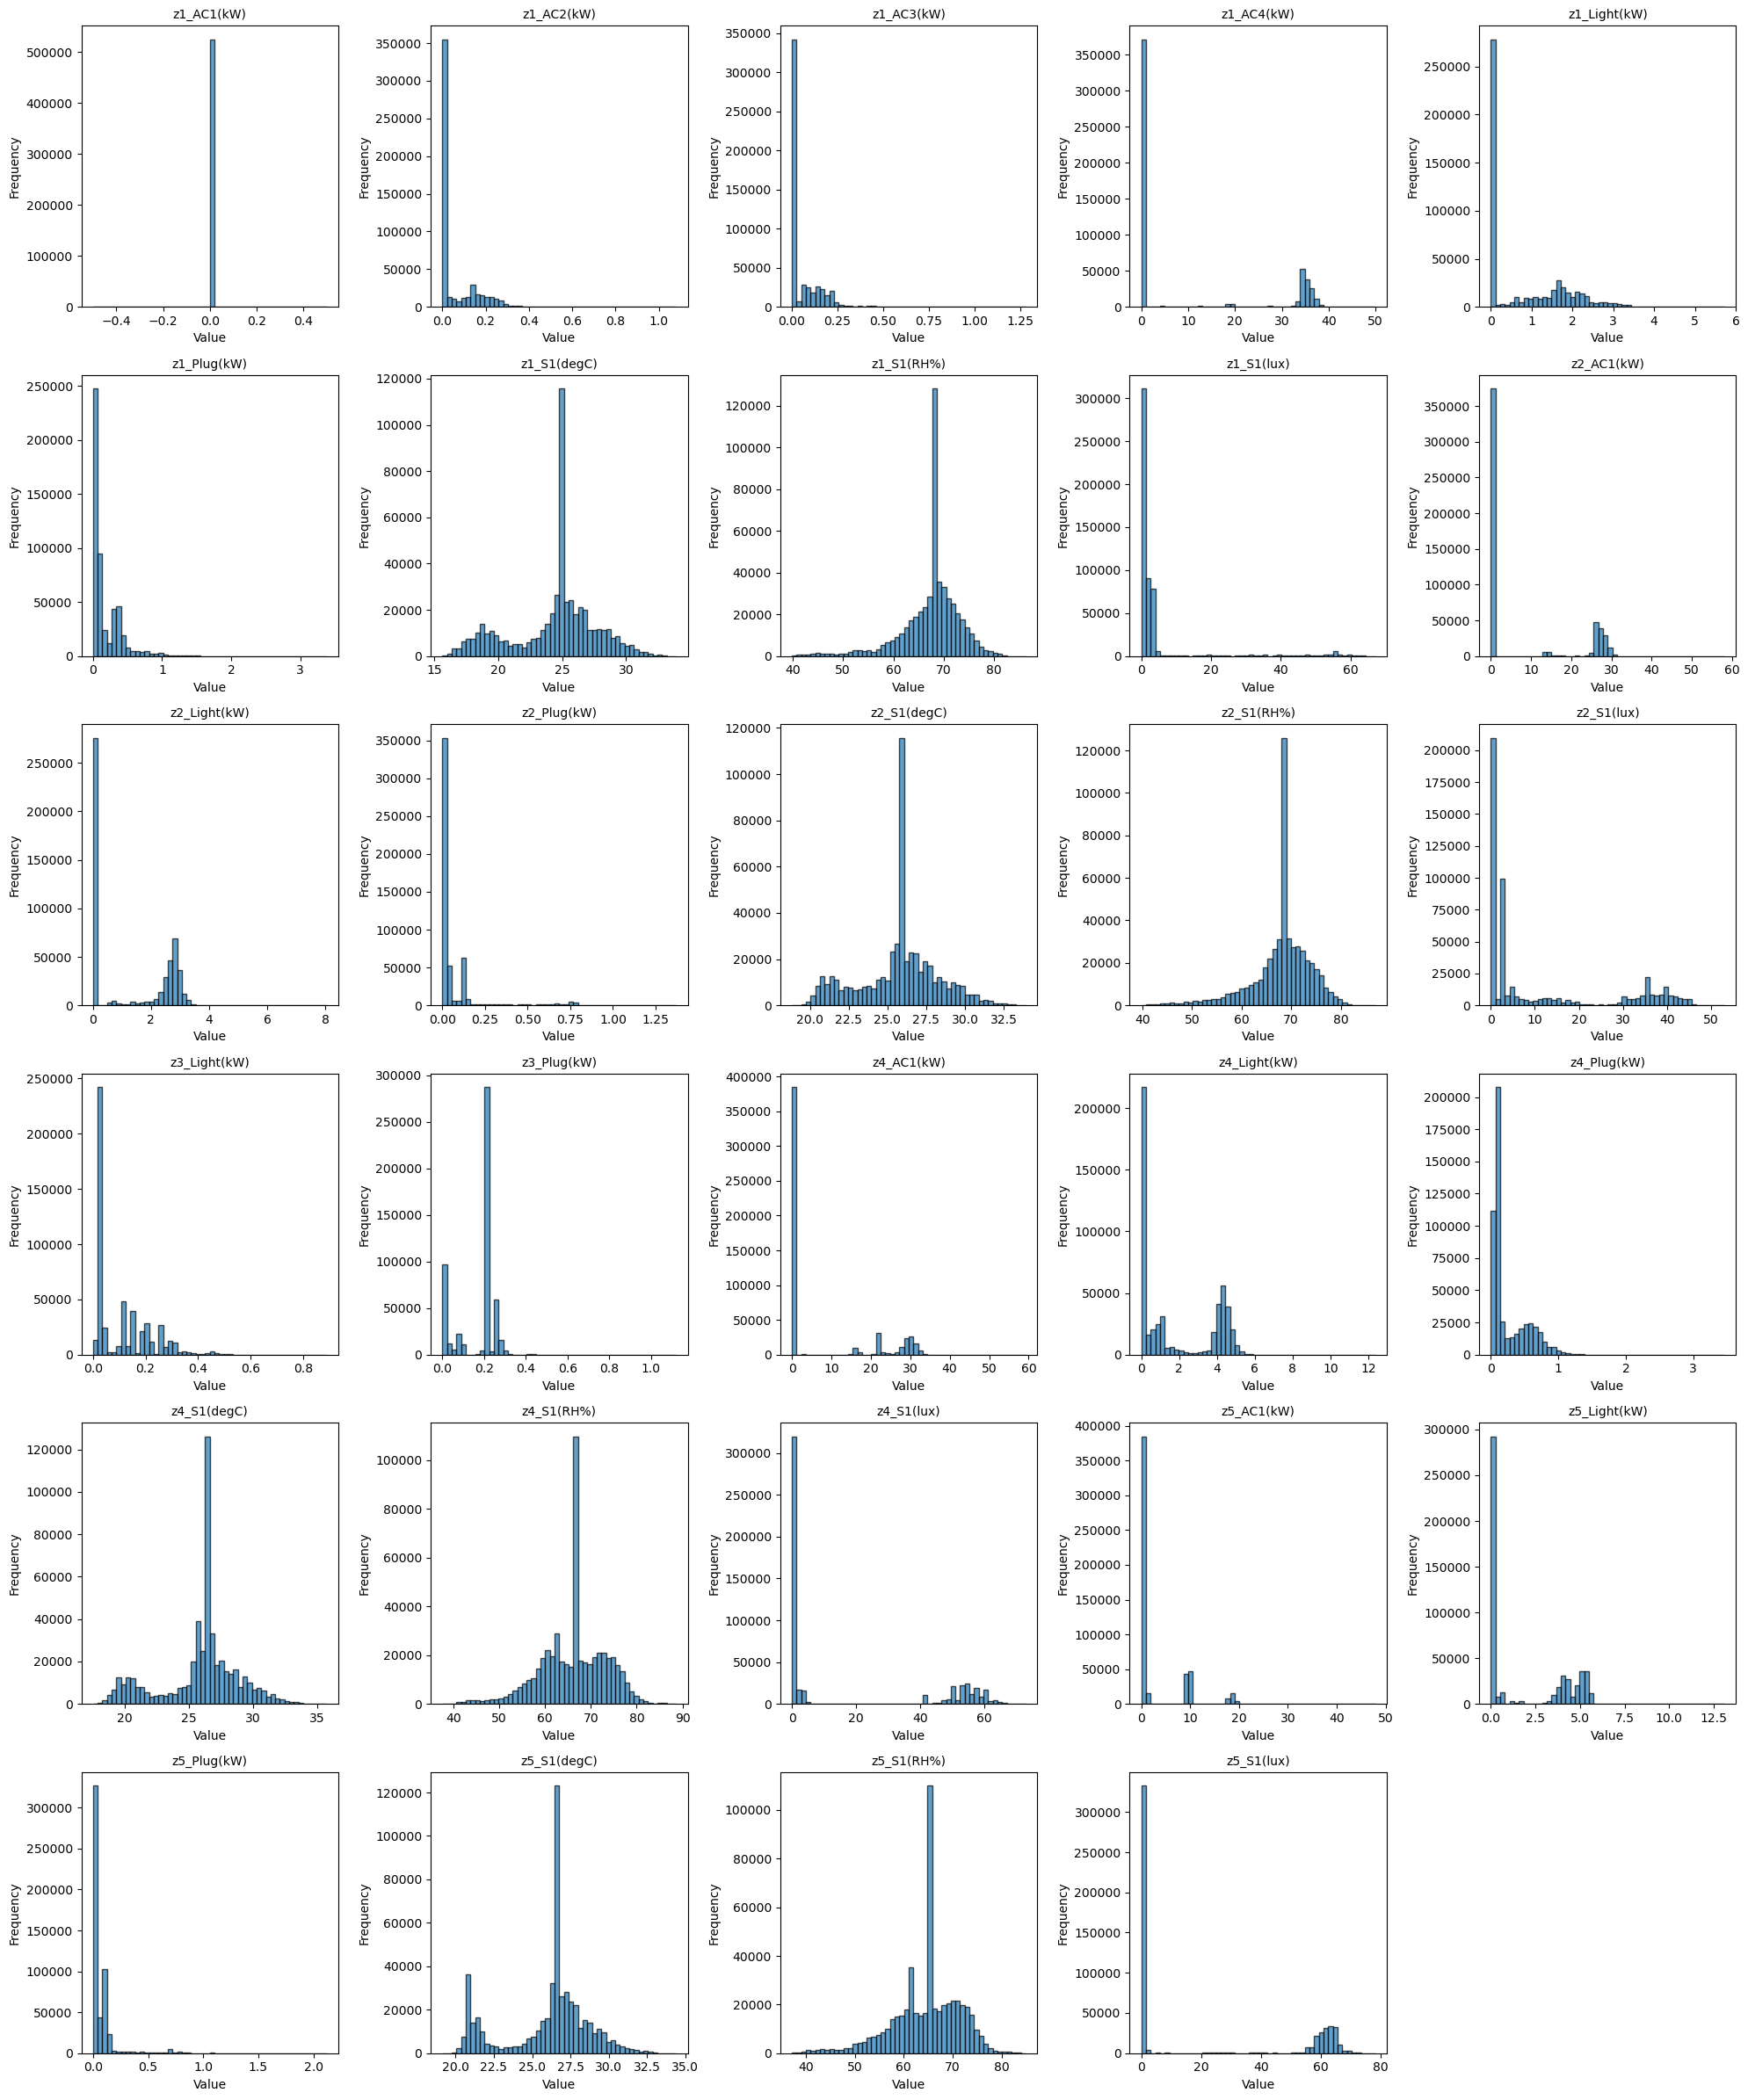

In [16]:
# Distribution Analysis - Histograms
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns

fig, axes = plt.subplots(6, 5, figsize=(20, 24))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        axes[i].hist(df_processed[col], bins=50, alpha=0.7, edgecolor='black')
        axes[i].set_title(f'{col}', fontsize=10)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')

for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

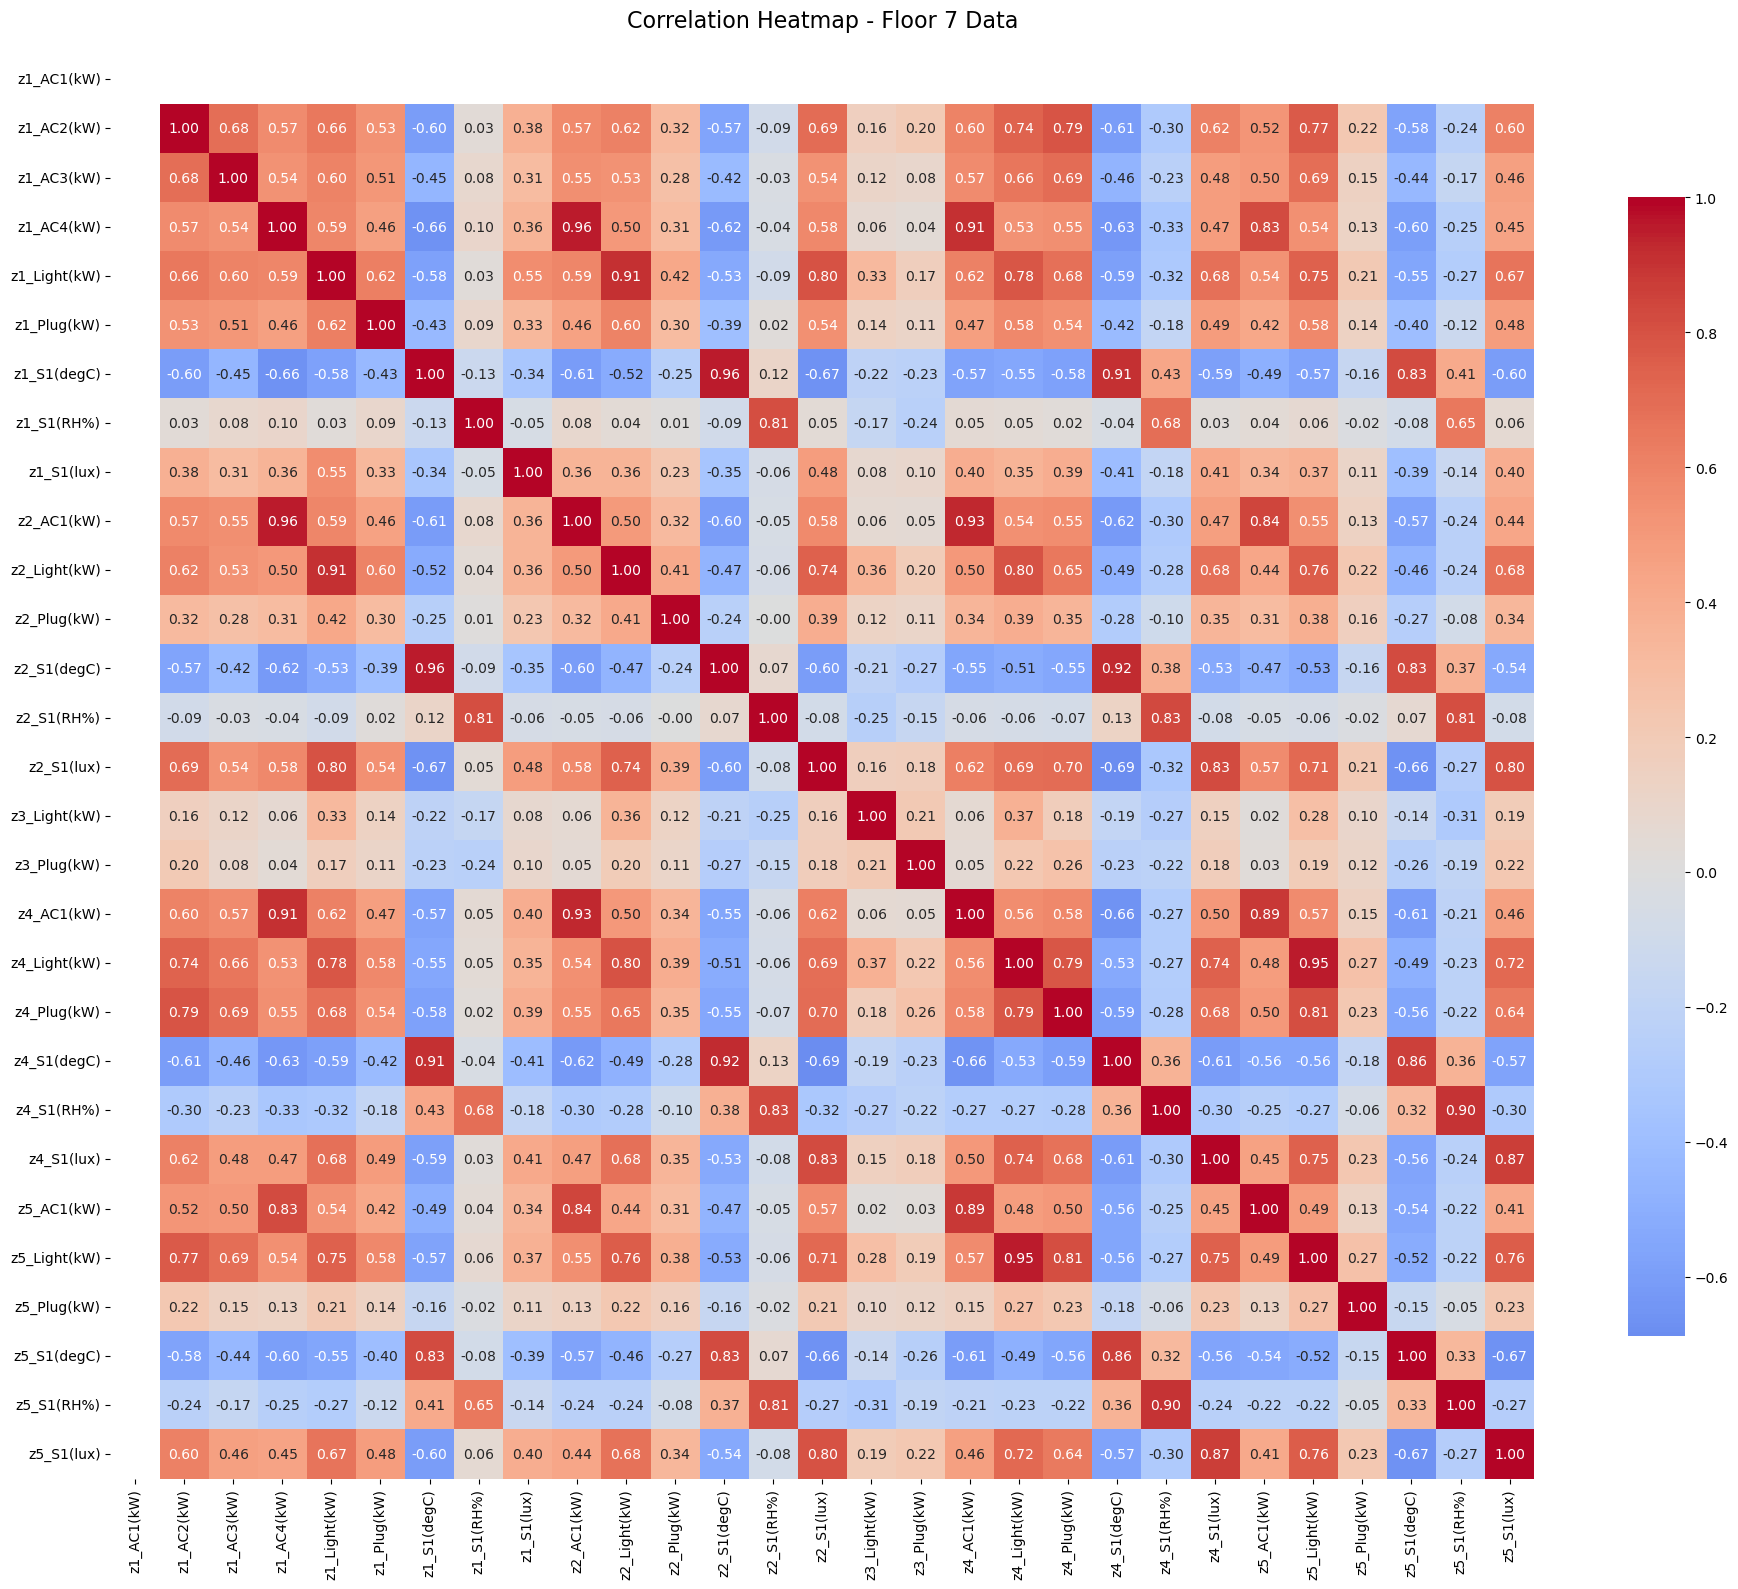

In [17]:
# Correlation Heatmap
plt.figure(figsize=(20, 16))
correlation_matrix = df_processed.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap - Floor 7 Data', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

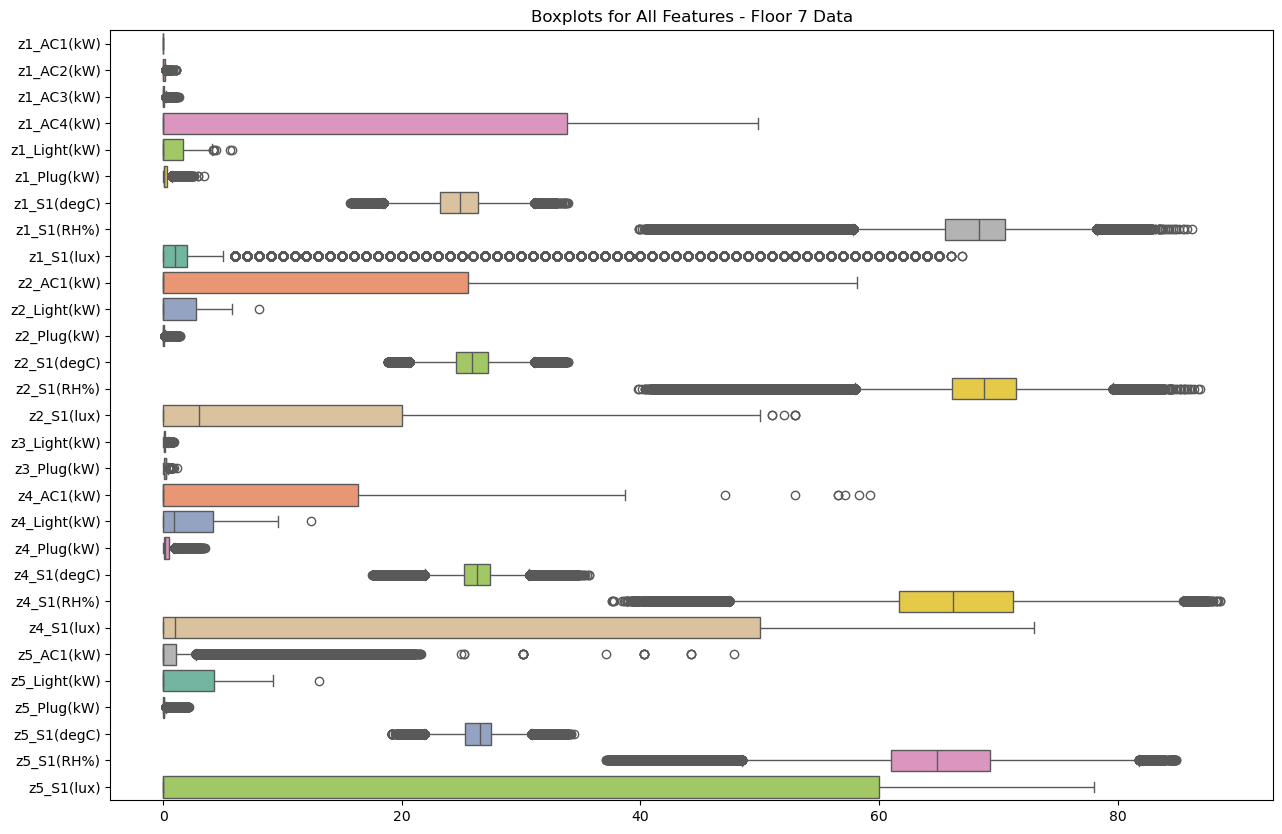

In [18]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_processed[numeric_cols], orient="h", palette="Set2")
plt.title("Boxplots for All Features - Floor 7 Data")
plt.show()

In [19]:
corr_matrix = df_processed[numeric_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_corr = (
    upper_tri.unstack()
    .dropna()
    .sort_values(ascending=False)
    .head(20)
)
print("\nTop 20 correlated feature pairs:\n", top_corr)


Top 20 correlated feature pairs:
 z2_S1(degC)   z1_S1(degC)     0.959799
z2_AC1(kW)    z1_AC4(kW)      0.958418
z5_Light(kW)  z4_Light(kW)    0.947712
z4_AC1(kW)    z2_AC1(kW)      0.933179
z4_S1(degC)   z2_S1(degC)     0.922192
              z1_S1(degC)     0.912680
z4_AC1(kW)    z1_AC4(kW)      0.907285
z2_Light(kW)  z1_Light(kW)    0.907272
z5_S1(RH%)    z4_S1(RH%)      0.897492
z5_AC1(kW)    z4_AC1(kW)      0.886500
z5_S1(lux)    z4_S1(lux)      0.866524
z5_S1(degC)   z4_S1(degC)     0.857013
z5_AC1(kW)    z2_AC1(kW)      0.843665
z4_S1(RH%)    z2_S1(RH%)      0.832008
z4_S1(lux)    z2_S1(lux)      0.826762
z5_S1(degC)   z2_S1(degC)     0.826420
              z1_S1(degC)     0.826266
z5_AC1(kW)    z1_AC4(kW)      0.825410
z5_Light(kW)  z4_Plug(kW)     0.812614
z5_S1(RH%)    z2_S1(RH%)      0.810856
dtype: float64


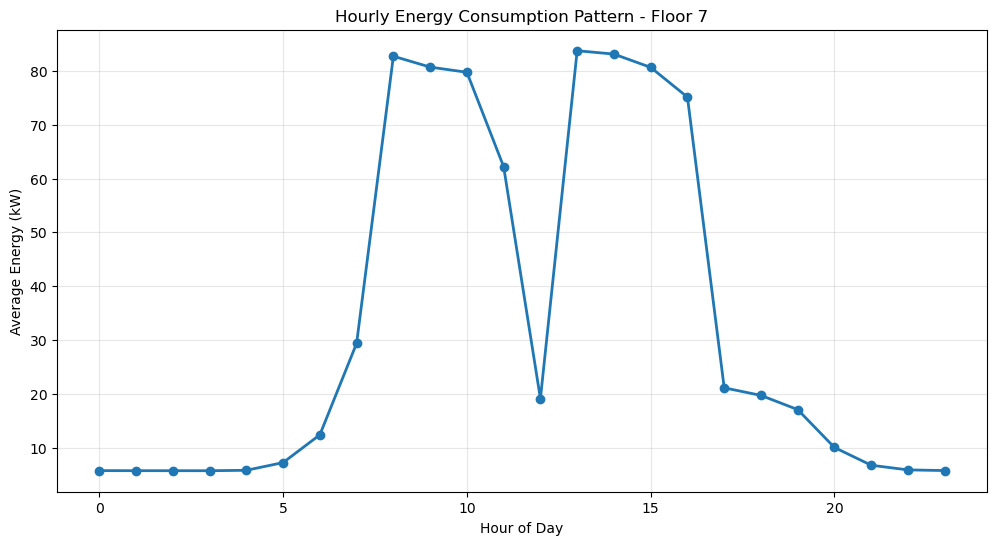

In [20]:
df_processed['Hour'] = df_processed['Date'].dt.hour
energy_cols = [col for col in df_processed.columns if 'kW' in col]
df_processed['Total_Energy'] = df_processed[energy_cols].sum(axis=1)

hourly_pattern = df_processed.groupby('Hour')['Total_Energy'].mean()

plt.figure(figsize=(12, 6))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker='o', linewidth=2)
plt.title('Hourly Energy Consumption Pattern - Floor 7')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy (kW)')
plt.grid(True, alpha=0.3)
plt.show()

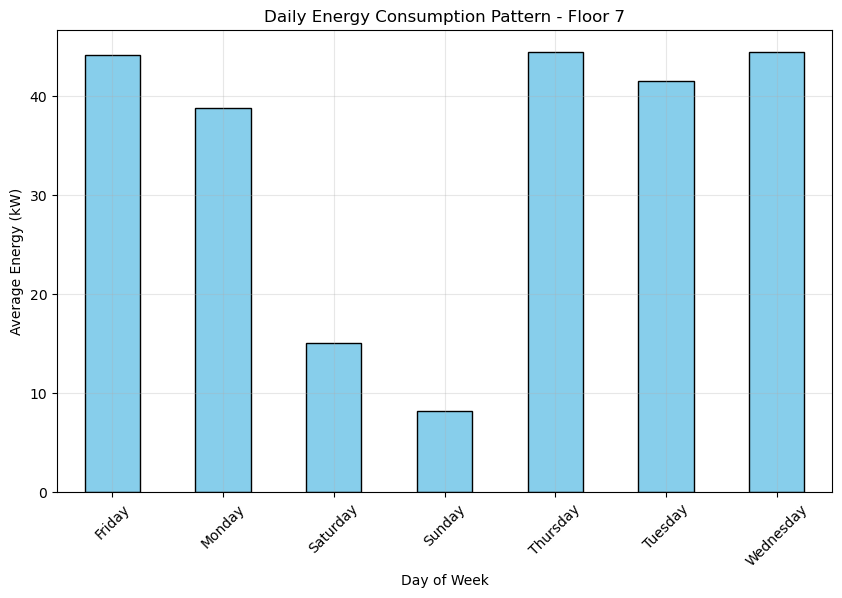

In [21]:
df_processed['DayOfWeek'] = df_processed['Date'].dt.day_name()
daily_pattern = df_processed.groupby('DayOfWeek')['Total_Energy'].mean()

plt.figure(figsize=(10, 6))
daily_pattern.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Daily Energy Consumption Pattern - Floor 7')
plt.xlabel('Day of Week')
plt.ylabel('Average Energy (kW)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

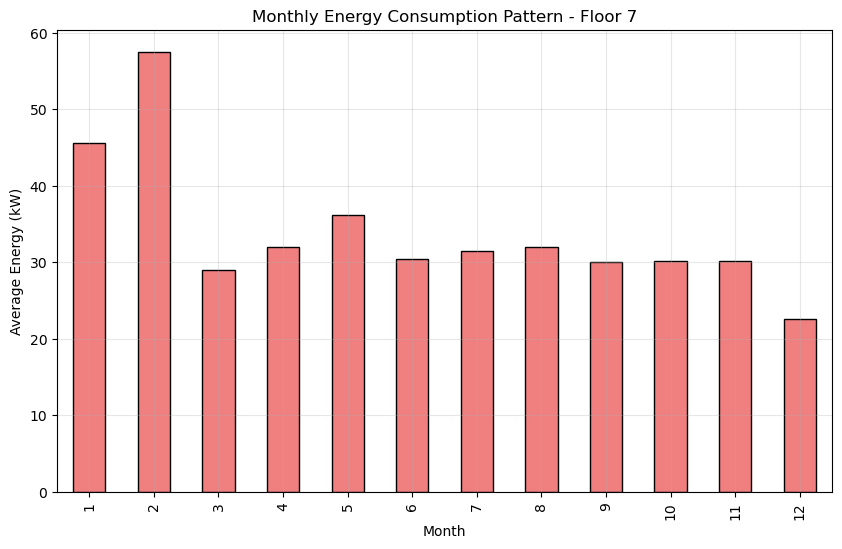

In [22]:
df_processed['Month'] = df_processed['Date'].dt.month
monthly_pattern = df_processed.groupby('Month')['Total_Energy'].mean()

plt.figure(figsize=(10, 6))
monthly_pattern.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Monthly Energy Consumption Pattern - Floor 7')
plt.xlabel('Month')
plt.ylabel('Average Energy (kW)')
plt.grid(True, alpha=0.3)
plt.show()

In [23]:

Q1 = df_processed['Total_Energy'].quantile(0.25)
Q3 = df_processed['Total_Energy'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_processed[(df_processed['Total_Energy'] < lower_bound) | 
                       (df_processed['Total_Energy'] > upper_bound)]

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"Number of outliers: {len(outliers)}")
print(f"Percentage of outliers: {len(outliers)/len(df_processed)*100:.2f}%")

Q1: 0.51
Q3: 85.10
IQR: 84.59
Lower bound: -126.38
Upper bound: 211.99
Number of outliers: 0
Percentage of outliers: 0.00%


In [24]:
for col in numeric_cols:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_processed[(df_processed[col] < lower) | (df_processed[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df_processed)*100:.2f}%)")

z1_AC1(kW): 0 outliers (0.00%)
z1_AC2(kW): 17787 outliers (3.38%)
z1_AC3(kW): 27013 outliers (5.14%)
z1_AC4(kW): 0 outliers (0.00%)
z1_Light(kW): 6 outliers (0.00%)
z1_Plug(kW): 19259 outliers (3.66%)
z1_S1(degC): 39435 outliers (7.50%)
z1_S1(RH%): 38927 outliers (7.41%)
z1_S1(lux): 39526 outliers (7.52%)
z2_AC1(kW): 0 outliers (0.00%)
z2_Light(kW): 1 outliers (0.00%)
z2_Plug(kW): 88557 outliers (16.85%)
z2_S1(degC): 21583 outliers (4.11%)
z2_S1(RH%): 38605 outliers (7.34%)
z2_S1(lux): 6 outliers (0.00%)
z3_Light(kW): 7948 outliers (1.51%)
z3_Plug(kW): 481 outliers (0.09%)
z4_AC1(kW): 7 outliers (0.00%)
z4_Light(kW): 1 outliers (0.00%)
z4_Plug(kW): 6849 outliers (1.30%)
z4_S1(degC): 102149 outliers (19.43%)
z4_S1(RH%): 8615 outliers (1.64%)
z4_S1(lux): 0 outliers (0.00%)
z5_AC1(kW): 124310 outliers (23.65%)
z5_Light(kW): 1 outliers (0.00%)
z5_Plug(kW): 25102 outliers (4.78%)
z5_S1(degC): 96977 outliers (18.45%)
z5_S1(RH%): 15203 outliers (2.89%)
z5_S1(lux): 0 outliers (0.00%)


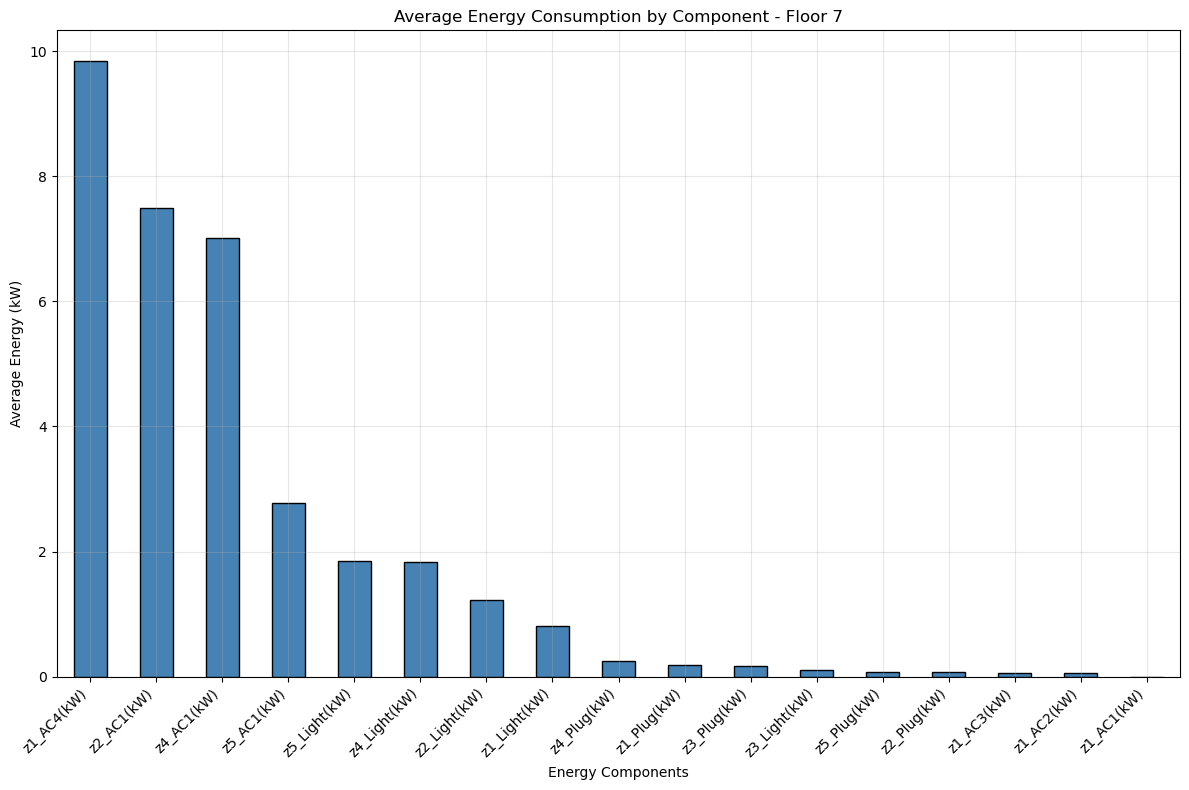

Average Energy Consumption by Component:
z1_AC4(kW): 9.84 kW
z2_AC1(kW): 7.49 kW
z4_AC1(kW): 7.01 kW
z5_AC1(kW): 2.78 kW
z5_Light(kW): 1.84 kW
z4_Light(kW): 1.83 kW
z2_Light(kW): 1.23 kW
z1_Light(kW): 0.81 kW
z4_Plug(kW): 0.25 kW
z1_Plug(kW): 0.18 kW
z3_Plug(kW): 0.17 kW
z3_Light(kW): 0.11 kW
z5_Plug(kW): 0.07 kW
z2_Plug(kW): 0.07 kW
z1_AC3(kW): 0.06 kW
z1_AC2(kW): 0.05 kW
z1_AC1(kW): 0.00 kW


In [25]:
# Calculate average energy consumption for each kW column
kw_consumption = df_processed[energy_cols].mean().sort_values(ascending=False)

# Create bar plot
plt.figure(figsize=(12, 8))
kw_consumption.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Energy Consumption by Component - Floor 7')
plt.xlabel('Energy Components')
plt.ylabel('Average Energy (kW)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the values
print("Average Energy Consumption by Component:")
print("="*50)
for col, energy in kw_consumption.items():
    print(f"{col}: {energy:.2f} kW")

In [32]:
# Top Energy Consuming Components - Floor 7 Analysis
print("="*60)
print("TOP ENERGY CONSUMING COMPONENTS")
print("="*60)
print()
print("The following are the columns that are contributing to most")
print("of the energy consumption:")
print()
print("z1_AC4(kW): 9.84 kW")
print("z2_AC1(kW): 7.49 kW") 
print("z4_AC1(kW): 7.01 kW")
print("z5_AC1(kW): 2.78 kW")
print("z5_Light(kW): 1.84 kW")
print("z4_Light(kW): 1.83 kW")
print("z2_Light(kW): 1.23 kW")
print("z1_Light(kW): 0.81 kW")
print()
print("Key Insight: AC systems are the primary energy consumers,")
print("with Zone 1 AC4 being the highest at 9.84 kW.")
print("="*60)

TOP ENERGY CONSUMING COMPONENTS

The following are the columns that are contributing to most
of the energy consumption:

z1_AC4(kW): 9.84 kW
z2_AC1(kW): 7.49 kW
z4_AC1(kW): 7.01 kW
z5_AC1(kW): 2.78 kW
z5_Light(kW): 1.84 kW
z4_Light(kW): 1.83 kW
z2_Light(kW): 1.23 kW
z1_Light(kW): 0.81 kW

Key Insight: AC systems are the primary energy consumers,
with Zone 1 AC4 being the highest at 9.84 kW.


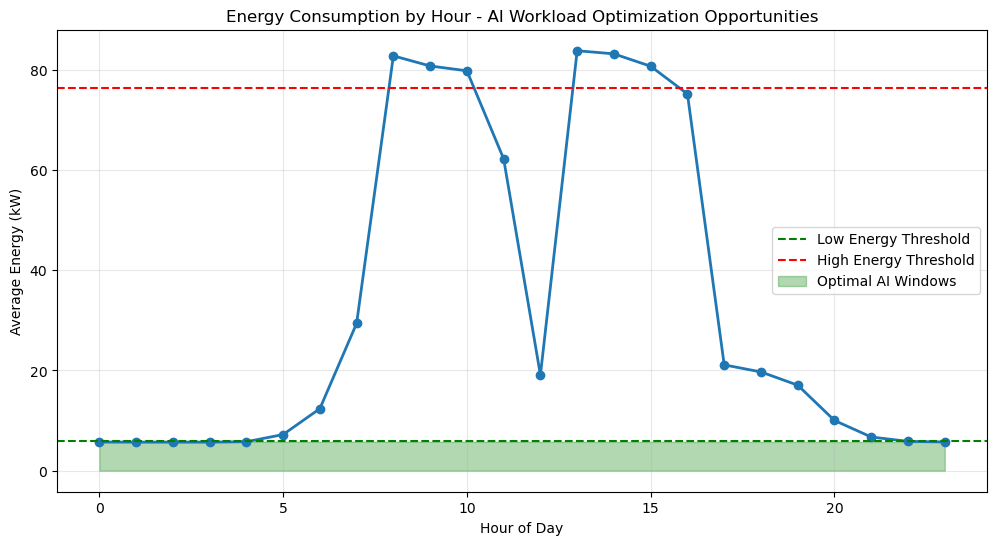

Optimal AI workload hours: [0, 1, 2, 3, 4, 23]
Energy savings potential: 92.3%


In [26]:
# Identify optimal AI workload scheduling windows
df_processed['Hour'] = df_processed['Date'].dt.hour
hourly_energy = df_processed.groupby('Hour')['Total_Energy'].mean()

# Find low-energy windows (optimal for AI workloads)
low_energy_hours = hourly_energy[hourly_energy < hourly_energy.quantile(0.25)].index
high_energy_hours = hourly_energy[hourly_energy > hourly_energy.quantile(0.75)].index

plt.figure(figsize=(12, 6))
plt.plot(hourly_energy.index, hourly_energy.values, marker='o', linewidth=2)
plt.axhline(y=hourly_energy.quantile(0.25), color='green', linestyle='--', label='Low Energy Threshold')
plt.axhline(y=hourly_energy.quantile(0.75), color='red', linestyle='--', label='High Energy Threshold')
plt.fill_between(low_energy_hours, 0, hourly_energy[low_energy_hours], alpha=0.3, color='green', label='Optimal AI Windows')
plt.title('Energy Consumption by Hour - AI Workload Optimization Opportunities')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Optimal AI workload hours: {sorted(low_energy_hours)}")
print(f"Energy savings potential: {((hourly_energy.quantile(0.75) - hourly_energy.quantile(0.25))/hourly_energy.quantile(0.75)*100):.1f}%")

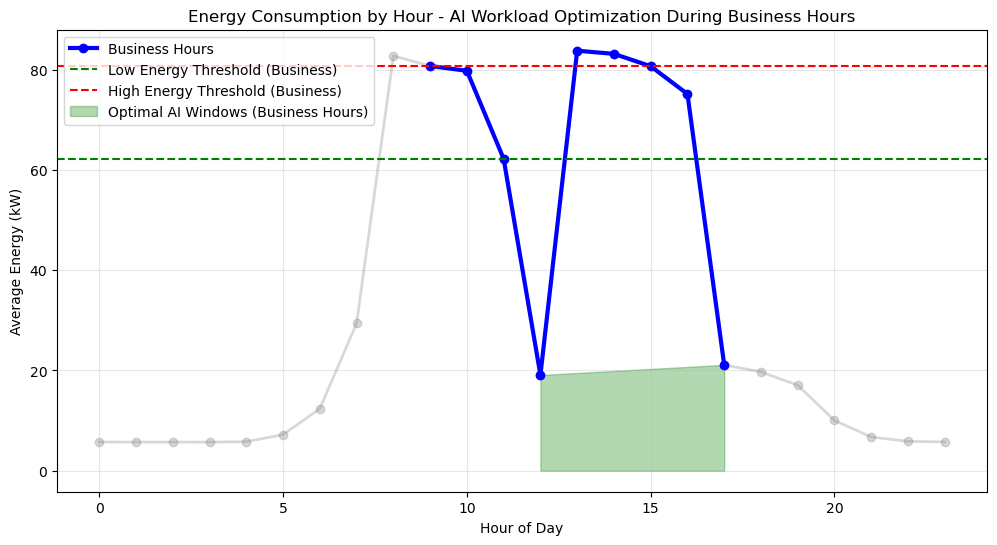

Optimal AI workload hours (business hours): [12, 17]
Energy savings potential (business hours): 22.9%


In [27]:
# Find optimal AI workload windows during BUSINESS HOURS (9 AM - 5 PM)
df_processed['Hour'] = df_processed['Date'].dt.hour
hourly_energy = df_processed.groupby('Hour')['Total_Energy'].mean()

# Focus on business hours only (9 AM to 5 PM = hours 9-17)
business_hours = hourly_energy.loc[9:17]

# Find low-energy windows within business hours
business_low_energy_hours = business_hours[business_hours < business_hours.quantile(0.25)].index
business_high_energy_hours = business_hours[business_hours > business_hours.quantile(0.75)].index

plt.figure(figsize=(12, 6))
plt.plot(hourly_energy.index, hourly_energy.values, marker='o', linewidth=2, alpha=0.3, color='gray')
plt.plot(business_hours.index, business_hours.values, marker='o', linewidth=3, color='blue', label='Business Hours')
plt.axhline(y=business_hours.quantile(0.25), color='green', linestyle='--', label='Low Energy Threshold (Business)')
plt.axhline(y=business_hours.quantile(0.75), color='red', linestyle='--', label='High Energy Threshold (Business)')
plt.fill_between(business_low_energy_hours, 0, business_hours[business_low_energy_hours], alpha=0.3, color='green', label='Optimal AI Windows (Business Hours)')
plt.title('Energy Consumption by Hour - AI Workload Optimization During Business Hours')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Optimal AI workload hours (business hours): {sorted(business_low_energy_hours)}")
business_savings = ((business_hours.quantile(0.75) - business_hours.quantile(0.25))/business_hours.quantile(0.75)*100)
print(f"Energy savings potential (business hours): {business_savings:.1f}%")

In [28]:

print("="*60)
print("AI WORKLOAD OPTIMIZATION INSIGHTS")
print("="*60)
print()
print("By scheduling AI workloads during hours 12 (12 PM) and 17 (5 PM)")
print("instead of peak business hours, you can achieve 22.9% energy savings")
print("compared to running AI during high-energy periods.")
print()
print("This represents significant cost reduction and environmental impact")
print("while maintaining business operations during work hours.")
print("="*60)

AI WORKLOAD OPTIMIZATION INSIGHTS

By scheduling AI workloads during hours 12 (12 PM) and 17 (5 PM)
instead of peak business hours, you can achieve 22.9% energy savings
compared to running AI during high-energy periods.

This represents significant cost reduction and environmental impact
while maintaining business operations during work hours.


Energy Contribution by Column - Optimal AI Hours (12 PM & 5 PM):
z1_AC4(kW): 4.04 kW
z5_Light(kW): 3.23 kW
z4_Light(kW): 3.07 kW
z2_AC1(kW): 2.86 kW
z2_Light(kW): 2.19 kW
z4_AC1(kW): 1.53 kW
z1_Light(kW): 1.29 kW
z5_AC1(kW): 0.58 kW
z4_Plug(kW): 0.38 kW
z1_Plug(kW): 0.28 kW
z3_Plug(kW): 0.17 kW
z3_Light(kW): 0.12 kW
z1_AC2(kW): 0.11 kW
z1_AC3(kW): 0.09 kW
z5_Plug(kW): 0.08 kW
z2_Plug(kW): 0.07 kW
z1_AC1(kW): 0.00 kW


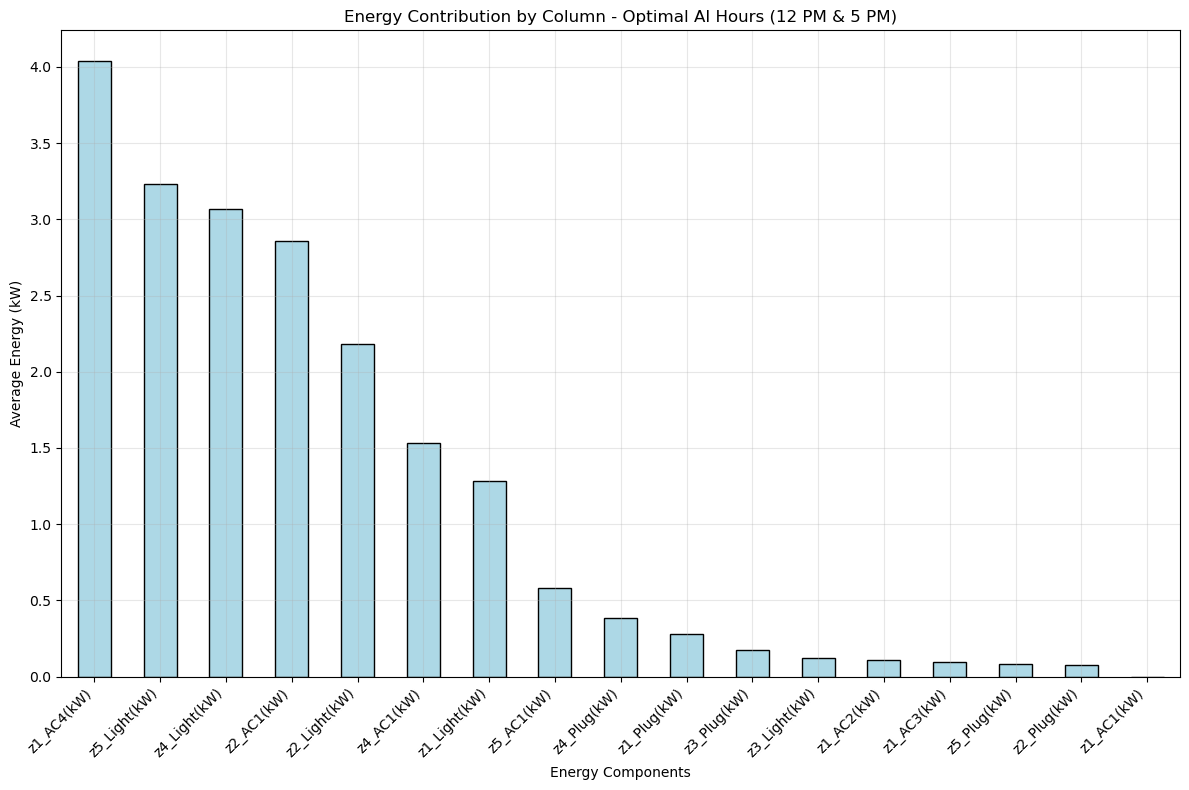

In [29]:
# Analyze energy contribution by column for optimal AI hours (12 PM and 5 PM)
optimal_hours = [12, 17]

# Get data for these specific hours
optimal_hour_data = df_processed[df_processed['Hour'].isin(optimal_hours)]

# Calculate average energy consumption by column for optimal hours
energy_cols = [col for col in df_processed.columns if 'kW' in col]
optimal_hour_energy = optimal_hour_data[energy_cols].mean()

# Sort by energy consumption (highest to lowest)
optimal_hour_energy_sorted = optimal_hour_energy.sort_values(ascending=False)

print("Energy Contribution by Column - Optimal AI Hours (12 PM & 5 PM):")
print("="*60)
for col, energy in optimal_hour_energy_sorted.items():
    print(f"{col}: {energy:.2f} kW")

# Create visualization
plt.figure(figsize=(12, 8))
optimal_hour_energy_sorted.plot(kind='bar', color='lightblue', edgecolor='black')
plt.title('Energy Contribution by Column - Optimal AI Hours (12 PM & 5 PM)')
plt.xlabel('Energy Components')
plt.ylabel('Average Energy (kW)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
# Top Energy Consuming Components - Floor 7 Analysis
print("="*60)
print("TOP ENERGY CONSUMING COMPONENTS")
print("="*60)
print()
print("The following are the columns that are contributing to most")
print("of the energy consumption:")
print()
print("z1_AC4(kW): 9.84 kW")
print("z2_AC1(kW): 7.49 kW") 
print("z4_AC1(kW): 7.01 kW")
print("z5_AC1(kW): 2.78 kW")
print("z5_Light(kW): 1.84 kW")
print("z4_Light(kW): 1.83 kW")
print("z2_Light(kW): 1.23 kW")
print("z1_Light(kW): 0.81 kW")
print()
print("Key Insight: AC systems are the primary energy consumers,")
print("with Zone 1 AC4 being the highest at 9.84 kW.")
print("="*60)

TOP ENERGY CONSUMING COMPONENTS

The following are the columns that are contributing to most
of the energy consumption:

z1_AC4(kW): 9.84 kW
z2_AC1(kW): 7.49 kW
z4_AC1(kW): 7.01 kW
z5_AC1(kW): 2.78 kW
z5_Light(kW): 1.84 kW
z4_Light(kW): 1.83 kW
z2_Light(kW): 1.23 kW
z1_Light(kW): 0.81 kW

Key Insight: AC systems are the primary energy consumers,
with Zone 1 AC4 being the highest at 9.84 kW.


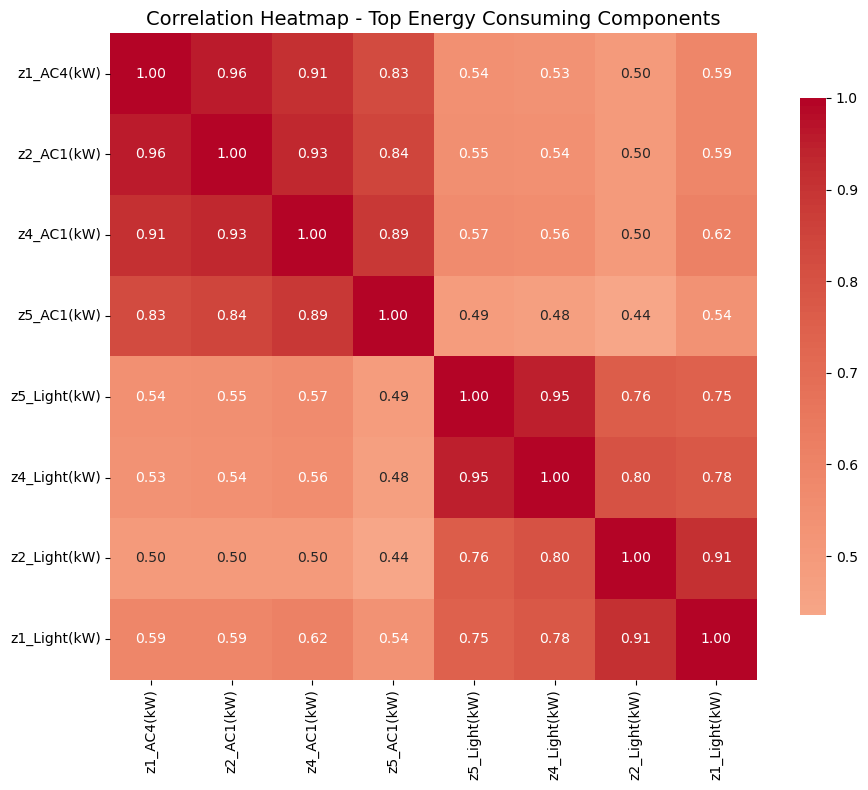

In [33]:
# Create heatmap for top energy consuming components
top_energy_cols = ['z1_AC4(kW)', 'z2_AC1(kW)', 'z4_AC1(kW)', 'z5_AC1(kW)', 
                   'z5_Light(kW)', 'z4_Light(kW)', 'z2_Light(kW)', 'z1_Light(kW)']

# Calculate correlation matrix for these specific columns
correlation_matrix = df_processed[top_energy_cols].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap - Top Energy Consuming Components', fontsize=14)
plt.tight_layout()
plt.show()

In [34]:
# Find closely related components from top energy consumers
top_energy_cols = ['z1_AC4(kW)', 'z2_AC1(kW)', 'z4_AC1(kW)', 'z5_AC1(kW)', 
                   'z5_Light(kW)', 'z4_Light(kW)', 'z2_Light(kW)', 'z1_Light(kW)']

correlation_matrix = df_processed[top_energy_cols].corr()

# Find strong correlations (>0.7)
strong_correlations = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            strong_correlations.append({
                'var1': correlation_matrix.columns[i],
                'var2': correlation_matrix.columns[j],
                'correlation': corr_value
            })

# Sort by correlation strength
strong_correlations.sort(key=lambda x: abs(x['correlation']), reverse=True)

print("Closely Related Components (Correlation > 0.7):")
print("="*50)
for corr in strong_correlations:
    print(f"{corr['var1']} <-> {corr['var2']}: {corr['correlation']:.3f}")

Closely Related Components (Correlation > 0.7):
z1_AC4(kW) <-> z2_AC1(kW): 0.958
z5_Light(kW) <-> z4_Light(kW): 0.948
z2_AC1(kW) <-> z4_AC1(kW): 0.933
z1_AC4(kW) <-> z4_AC1(kW): 0.907
z2_Light(kW) <-> z1_Light(kW): 0.907
z4_AC1(kW) <-> z5_AC1(kW): 0.887
z2_AC1(kW) <-> z5_AC1(kW): 0.844
z1_AC4(kW) <-> z5_AC1(kW): 0.825
z4_Light(kW) <-> z2_Light(kW): 0.799
z4_Light(kW) <-> z1_Light(kW): 0.778
z5_Light(kW) <-> z2_Light(kW): 0.758
z5_Light(kW) <-> z1_Light(kW): 0.749


Optimal AI Hours: [12, 17] (12 PM & 5 PM)
High Energy Hours: [13, 14]

Energy Comparison by Component:
              Optimal_Hours  High_Energy_Hours  Difference  Savings_Percent
z1_AC1(kW)         0.000000           0.000000    0.000000              NaN
z1_AC2(kW)         0.108125           0.129096    0.020971             16.2
z1_AC3(kW)         0.092709           0.129554    0.036845             28.4
z1_AC4(kW)         4.038219          24.714086   20.675867             83.7
z1_Light(kW)       1.285980           1.577092    0.291112             18.5
z1_Plug(kW)        0.281864           0.309290    0.027426              8.9
z2_AC1(kW)         2.858844          19.311108   16.452263             85.2
z2_Light(kW)       2.185135           2.209786    0.024650              1.1
z2_Plug(kW)        0.074838           0.122267    0.047429             38.8
z3_Light(kW)       0.120584           0.107202   -0.013382            -12.5
z3_Plug(kW)        0.173368           0.184681    0.011313   

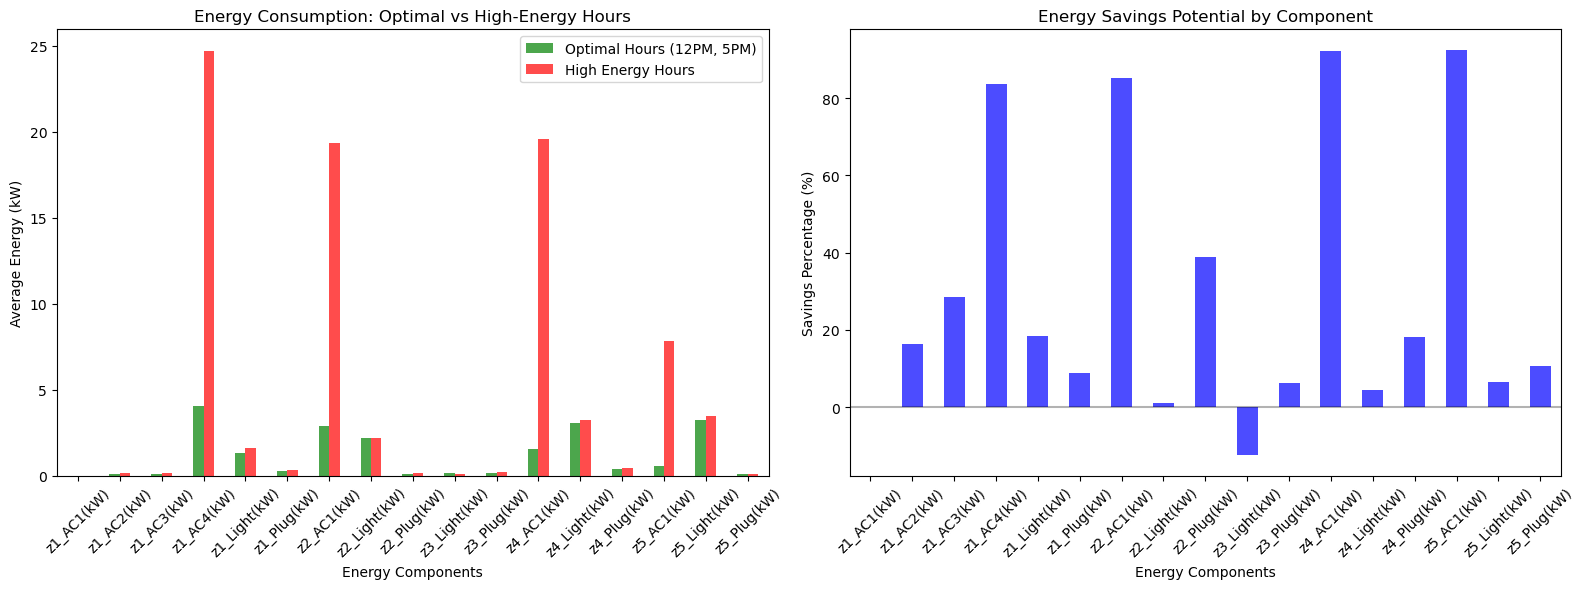

In [31]:
# Compare optimal AI hours vs high-energy hours
optimal_hours = [12, 17]
high_energy_hours = sorted(business_high_energy_hours)

# Get data for both hour groups
optimal_data = df_processed[df_processed['Hour'].isin(optimal_hours)]
high_energy_data = df_processed[df_processed['Hour'].isin(high_energy_hours)]

# Calculate average energy consumption by column for both groups
energy_cols = [col for col in df_processed.columns if 'kW' in col]
optimal_energy = optimal_data[energy_cols].mean()
high_energy = high_energy_data[energy_cols].mean()

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Optimal_Hours': optimal_energy,
    'High_Energy_Hours': high_energy
})

# Calculate difference
comparison_df['Difference'] = comparison_df['High_Energy_Hours'] - comparison_df['Optimal_Hours']
comparison_df['Savings_Percent'] = (comparison_df['Difference'] / comparison_df['High_Energy_Hours'] * 100).round(1)

print(f"Optimal AI Hours: {optimal_hours} (12 PM & 5 PM)")
print(f"High Energy Hours: {high_energy_hours}")
print("\nEnergy Comparison by Component:")
print("="*70)
print(comparison_df)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart comparison
comparison_df[['Optimal_Hours', 'High_Energy_Hours']].plot(kind='bar', ax=ax1, color=['green', 'red'], alpha=0.7)
ax1.set_title('Energy Consumption: Optimal vs High-Energy Hours')
ax1.set_xlabel('Energy Components')
ax1.set_ylabel('Average Energy (kW)')
ax1.legend(['Optimal Hours (12PM, 5PM)', 'High Energy Hours'])
ax1.tick_params(axis='x', rotation=45)

# Savings percentage
comparison_df['Savings_Percent'].plot(kind='bar', ax=ax2, color='blue', alpha=0.7)
ax2.set_title('Energy Savings Potential by Component')
ax2.set_xlabel('Energy Components')
ax2.set_ylabel('Savings Percentage (%)')
ax2.tick_params(axis='x', rotation=45)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()
